In [13]:
import numpy as np
import pandas as pd
from scipy import stats 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns



In [14]:
import pandas as pd
 
# Originalfilen er semikolon-separeret, har et BOM-tegn i starten,
# og en række tomme "Unnamed" kolonner til sidst.
path = "/Users/noahwestheimer/Documents/DTU/2. semester/Sommer kurser/02445 project in statistical evaluation of aI/Group project/Project_in_statistical_evaluation_of_AI_-DATA_CSV_1 (1).csv"
 
df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
 
# Ryd op:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]   # fjern tomme kolonner
df.columns = df.columns.str.strip()                       # trim kolonnenavne
df["Q_Type"] = df["Q_Type"].str.strip().replace({"Knowlegde": "Knowledge"})  # ret stavefejl
 
df

,Examset,Question,Q_Type,Haiko True,Haiko False,Opus True,Opus False
0,Spring 2025,1,Visual,5,0,5,0
1,Spring 2025,2,Visual,0,5,5,0
2,Spring 2025,3,Computational,0,5,5,0
3,Spring 2025,4,Visual,4,1,4,1
4,Spring 2025,5,Knowledge,0,5,5,0
5,Spring 2025,6,Computational,1,4,5,0
6,Spring 2025,7,Computational,0,5,5,0
7,Spring 2025,8,Computational,0,5,5,0
8,Spring 2025,9,Visual,0,5,5,0
9,Spring 2025,10,Computational,0,5,1,4


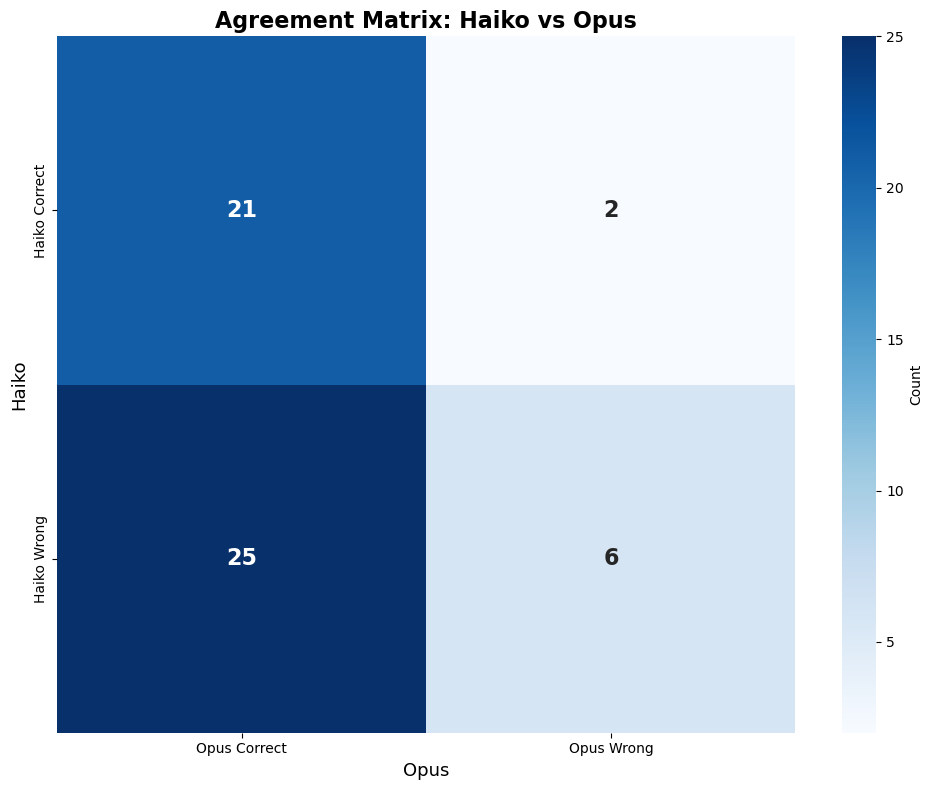

In [21]:

df['Haiko_Correct'] = (df['Haiko True'] > df['Haiko False']).astype(int)
df['Opus_Correct'] = (df['Opus True'] > df['Opus False']).astype(int)

# 2x2 matrix
n11 = ((df['Haiko_Correct'] == 1) & (df['Opus_Correct'] == 1)).sum()
n12 = ((df['Haiko_Correct'] == 1) & (df['Opus_Correct'] == 0)).sum()
n21 = ((df['Haiko_Correct'] == 0) & (df['Opus_Correct'] == 1)).sum()
n22 = ((df['Haiko_Correct'] == 0) & (df['Opus_Correct'] == 0)).sum()

matrix = np.array([[n11, n12], [n21, n22]])

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Opus Correct', 'Opus Wrong'],
            yticklabels=['Haiko Correct', 'Haiko Wrong'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

ax.set_title('Agreement Matrix: Haiko vs Opus', fontsize=16, fontweight='bold')
ax.set_xlabel('Opus', fontsize=13)
ax.set_ylabel('Haiko', fontsize=13)

plt.tight_layout()
plt.show()

/var/folders/fs/mwdr9m3n0tg_c48y2sp0j4l40000gn/T/ipykernel_11594/3647299931.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n11 = (df[df['Haiko_Correct'] == 1][df['Opus_Correct'] == 1]['Haiko True'].sum())


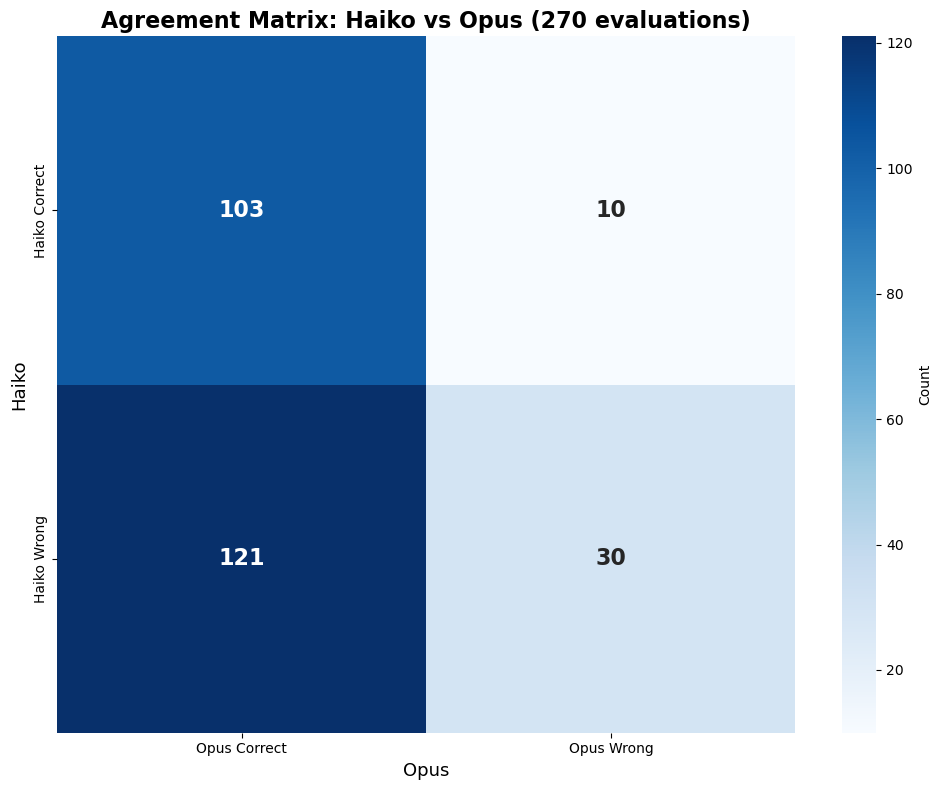

Both Correct (n11):           103
Haiko ✓, Opus ✗ (n12):        10
Haiko ✗, Opus ✓ (n21):        121
Both Wrong (n22):             30
Total:                        264


In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/Users/noahwestheimer/Documents/DTU/2. semester/Sommer kurser/02445 project in statistical evaluation of aI/Group project/Project_in_statistical_evaluation_of_AI_-DATA_CSV_1 (1).csv", 
                  sep=";", encoding="utf-8-sig")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()

df['Haiko_Correct'] = (df['Haiko True'] > df['Haiko False']).astype(int)
df['Opus_Correct'] = (df['Opus True'] > df['Opus False']).astype(int)

# 2x2 matrix - weight by actual counts
n11 = (df[df['Haiko_Correct'] == 1][df['Opus_Correct'] == 1]['Haiko True'].sum())
n12 = (df[(df['Haiko_Correct'] == 1) & (df['Opus_Correct'] == 0)]['Haiko True'].sum())
n21 = (df[(df['Haiko_Correct'] == 0) & (df['Opus_Correct'] == 1)]['Opus True'].sum())
n22 = (df[(df['Haiko_Correct'] == 0) & (df['Opus_Correct'] == 0)]['Haiko False'].sum())

matrix = np.array([[n11, n12], [n21, n22]])

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Opus Correct', 'Opus Wrong'],
            yticklabels=['Haiko Correct', 'Haiko Wrong'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

ax.set_title('Agreement Matrix: Haiko vs Opus (270 evaluations)', fontsize=16, fontweight='bold')
ax.set_xlabel('Opus', fontsize=13)
ax.set_ylabel('Haiko', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Both Correct (n11):           {n11}")
print(f"Haiko ✓, Opus ✗ (n12):        {n12}")
print(f"Haiko ✗, Opus ✓ (n21):        {n21}")
print(f"Both Wrong (n22):             {n22}")
print(f"Total:                        {n11 + n12 + n21 + n22}")

ACCURACY BY QUESTION TYPE

Overall:
  Haiko: 44.1%
  Opus:  85.6%
  Diff:  +41.5%

Computational:
  Haiko: 22.4%
  Opus:  95.3%
  Diff:  +72.9%

Knowlegde:
  Haiko: 60.0%
  Opus:  92.0%
  Diff:  +32.0%

Visual:
  Haiko: 51.9%
  Opus:  77.0%
  Diff:  +25.2%



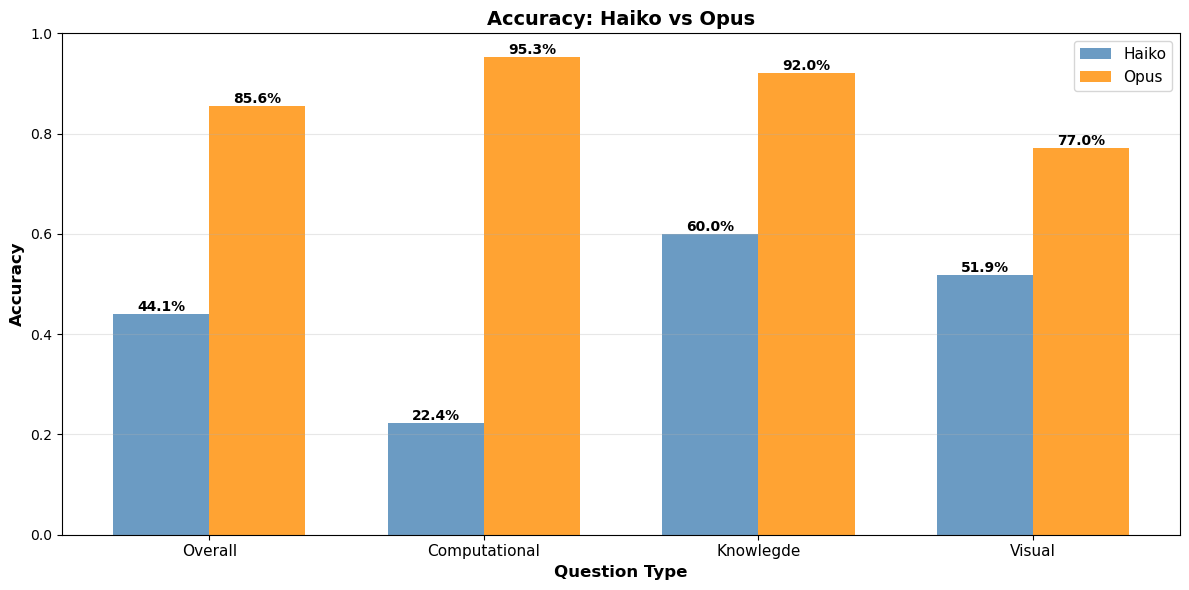

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("/Users/noahwestheimer/Documents/DTU/2. semester/Sommer kurser/02445 project in statistical evaluation of aI/Group project/Project_in_statistical_evaluation_of_AI_-DATA_CSV_1 (1).csv", 
                  sep=";", encoding="utf-8-sig")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()

# Overall accuracy
total_evaluations = len(df) * 5
haiko_total = df['Haiko True'].sum() / total_evaluations
opus_total = df['Opus True'].sum() / total_evaluations

# Accuracy by question type
q_types = df['Q_Type'].unique()
results = {'Overall': [haiko_total, opus_total]}

for qtype in sorted(q_types):
    subset = df[df['Q_Type'] == qtype]
    haiko_acc = subset['Haiko True'].sum() / (len(subset) * 5)
    opus_acc = subset['Opus True'].sum() / (len(subset) * 5)
    results[qtype] = [haiko_acc, opus_acc]

# Print results
print("=" * 60)
print("ACCURACY BY QUESTION TYPE")
print("=" * 60)

for qtype, accs in results.items():
    print(f"\n{qtype}:")
    print(f"  Haiko: {accs[0]:.1%}")
    print(f"  Opus:  {accs[1]:.1%}")
    print(f"  Diff:  {accs[1] - accs[0]:+.1%}")

print("\n" + "=" * 60)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results))
width = 0.35

haiko_vals = [results[k][0] for k in results.keys()]
opus_vals = [results[k][1] for k in results.keys()]

bars1 = ax.bar(x - width/2, haiko_vals, width, label='Haiko', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, opus_vals, width, label='Opus', color='darkorange', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Question Type', fontsize=12, fontweight='bold')
ax.set_title('Accuracy: Haiko vs Opus', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results.keys(), fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()